# Global Stage 2 — Feature 선택용 Train 내부 분석

이 Notebook은 `baseline_42features`의 **Global Train**과 Train 내부 `StratifiedGroupKFold` 결과만 사용한다. 최종 Test Dataset은 읽지 않는다.

Permutation Importance, Logistic Regression 계수, XGBoost gain/weight, 수치형 상관관계, VIF를 함께 보여 주지만 Feature를 자동으로 제거하거나 최종 목록을 만들지 않는다. 결과 해석과 Feature 선택은 사람이 직접 수행한다.

In [1]:
import importlib
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path(os.environ.get('KHUDA_PROJECT_ROOT', Path.cwd())).resolve()
while not (ROOT / 'code').is_dir():
    if ROOT.parent == ROOT:
        raise RuntimeError('KHUDA_PROJECT_ROOT에 저장소 루트를 지정하거나 저장소 안에서 Notebook을 실행하세요.')
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if 'code' in sys.modules and not hasattr(sys.modules['code'], '__path__'):
    del sys.modules['code']
# 외부에서 code/를 수정한 뒤에도 kernel을 재시작하지 않고 최신 분석 모듈을 읽는다.
for module_name in ('code.model.first_stage', 'code.evaluation.feature_analysis'):
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from code.evaluation.feature_analysis import (
    build_feature_selection_summary,
    calculate_numeric_vif,
    numeric_correlation_analysis,
    run_cv_feature_analysis,
)
from code.model.first_stage import load_first_stage_best_params
from code.model.train import load_model_config
from code.pipeline.saved_results import load_saved_global_train

EXPERIMENT = 'baseline_42features'
RESULT_ROOT = ROOT / 'data' / 'result' / EXPERIMENT
DATASET_PATH = RESULT_ROOT / 'datasets' / 'global_dataset.parquet'
SPLIT_PATH = RESULT_ROOT / 'splits' / 'split_ids.csv'
FEATURE_CONFIG = ROOT / 'code' / 'config' / 'features.yaml'
MODEL_CONFIG = ROOT / 'code' / 'config' / 'model_config.yaml'
STAGE_1_OUTPUT_DIR = RESULT_ROOT / 'modeling' / 'stage_1'
ANALYSIS_OUTPUT_DIR = RESULT_ROOT / 'modeling' / 'stage_2'
CORRELATION_PAIR_THRESHOLD = 0.70  # 높은 상관 pair를 표에 표시하는 기준일 뿐 삭제 기준이 아니다.

for path in (DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG, MODEL_CONFIG):
    if not path.exists():
        raise FileNotFoundError(f'필요한 Stage 2 입력 파일이 없습니다: {path}')

COLORS = {'logistic_regression': '#0066cc', 'xgboost': '#7a7a7a'}
LABELS = {'logistic_regression': 'Logistic Regression', 'xgboost': 'XGBoost'}
plt.rcParams.update({
    'figure.facecolor': '#f5f5f7', 'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#e0e0e0', 'text.color': '#1d1d1f',
    'axes.labelcolor': '#1d1d1f', 'xtick.color': '#1d1d1f', 'ytick.color': '#1d1d1f',
})

In [2]:
# Test Dataset을 만들지 않고 고정 SAMPID split의 Train만 읽는다.
train_bundle = load_saved_global_train(DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG)
model_config = load_model_config(MODEL_CONFIG)
official_models = model_config['official_comparison_models']
best_params = load_first_stage_best_params(STAGE_1_OUTPUT_DIR)

assert official_models == ['logistic_regression', 'xgboost']
assert train_bundle.X.shape[1] == 42
assert set(official_models).issubset(best_params)
display(pd.DataFrame({
    'item': ['Train Person-Periods', 'Train unique SAMPID', 'n_features', 'CV', 'permutation scoring', 'n_repeats'],
    'value': [
        len(train_bundle.y), train_bundle.groups.nunique(), train_bundle.X.shape[1],
        f"StratifiedGroupKFold({model_config['split']['cv_n_splits']}) / SAMPID",
        model_config['evaluation']['permutation_scoring'],
        model_config['evaluation']['permutation_repeats'],
    ],
}))
display(pd.DataFrame({'model': official_models, 'Stage 1 best_params': [best_params[name] for name in official_models]}))

,item,value
0,Train Person-Periods,11925
1,Train unique SAMPID,5737
2,n_features,42
3,CV,StratifiedGroupKFold(5) / SAMPID
4,permutation scoring,f1
5,n_repeats,20


,model,Stage 1 best_params
0,logistic_regression,"{'C': 1, 'class_weight': 'balanced', 'penalty'..."
1,xgboost,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."


## CV 기반 분석 실행

각 모델은 Stage 1에서 저장한 최적 파라미터를 사용한다. 매 CV fold에서 Train fold로만 전처리·학습하고 validation fold에서 원 Feature 단위 F1 Permutation Importance를 계산한다. XGBoost의 `scale_pos_weight`도 해당 CV Train fold의 class ratio로 계산된다.

In [3]:
# GridSearch를 다시 수행하지 않는다. Stage 1 best parameter로 5-fold 분석만 수행한다.
analyses = {}
for model_name in official_models:
    print(f"Running {LABELS[model_name]} CV feature analysis ...")
    analyses[model_name] = run_cv_feature_analysis(
        train_bundle.X, train_bundle.y, train_bundle.groups,
        model_name=model_name,
        params=best_params[model_name],
        feature_config=FEATURE_CONFIG,
        model_config=MODEL_CONFIG,
        # Jupyter 환경에서 process worker 충돌을 피하기 위해 permutation은 현재 kernel에서 실행한다.
        n_jobs=1,
    )

pearson, spearman, high_correlation_pairs = numeric_correlation_analysis(
    train_bundle.X, FEATURE_CONFIG, abs_threshold=CORRELATION_PAIR_THRESHOLD
)
vif_table, vif_scope = calculate_numeric_vif(train_bundle.X, FEATURE_CONFIG)
feature_summary = build_feature_selection_summary(
    list(train_bundle.X.columns),
    lr_analysis=analyses['logistic_regression'],
    xgb_analysis=analyses['xgboost'],
    pearson=pearson, spearman=spearman, vif_table=vif_table,
)

Running Logistic Regression CV feature analysis ...


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

Running XGBoost CV feature analysis ...


In [4]:
# 모든 원 Feature의 결과를 표로 확인한다. 이 표는 자동 선택이나 삭제를 수행하지 않는다.
display(analyses['logistic_regression'].permutation_summary)
display(analyses['xgboost'].permutation_summary)

# 계수는 예측 모델의 보조 자료이며 인과효과를 뜻하지 않는다.
display(analyses['logistic_regression'].coefficient_summary)

# XGBoost gain/weight는 permutation importance와 비교하는 보조 자료다.
display(analyses['xgboost'].xgb_importance)

display(high_correlation_pairs)
display(vif_scope)
display(vif_table)

,feature,importance_mean,importance_std,positive_fold_count,rank
0,student_status,0.032215,0.004080,5,1
1,months_since_graduation,0.012567,0.005924,5,2
2,ever_worked_before,0.011749,0.005354,5,3
3,recent_job_search,0.011293,0.005078,5,4
4,student_type,0.008005,0.005479,4,5
5,region_5,0.005752,0.005709,4,6
6,recent_employment_prep,0.005239,0.003530,5,7
7,education_level,0.005123,0.002164,5,8
8,age,0.003692,0.004617,4,9
9,nonemployment_type,0.002407,0.002130,5,10


,feature,importance_mean,importance_std,positive_fold_count,rank
0,student_status,0.036876,0.006774,5,1
1,age,0.022722,0.006381,5,2
2,months_since_graduation,0.017402,0.010665,5,3
3,recent_job_search,0.014002,0.003175,5,4
4,gender,0.006583,0.002349,5,5
5,ever_worked_before,0.005663,0.001502,5,6
6,major_group,0.005236,0.004945,4,7
7,region_5,0.004589,0.005056,3,8
8,university_type,0.004230,0.003846,4,9
9,recent_employment_prep,0.002179,0.003201,4,10


,feature,coefficient_mean,coefficient_magnitude,coefficient_abs_max,coefficient_direction
0,student_status,0.169592,0.277585,0.563261,positive
1,months_since_graduation,0.207575,0.207575,0.248874,positive
2,ever_worked_before,0.190336,0.190336,0.255601,positive
3,recent_job_search,0.186720,0.186720,0.219148,positive
4,university_type,0.058088,0.180145,0.384245,positive
5,age,0.129897,0.129897,0.167748,positive
6,nonemployment_type,0.088637,0.126432,0.340134,positive
7,recent_employment_prep,0.118715,0.118715,0.141867,positive
8,gender,-0.016795,0.103737,0.159457,negative
9,education_level,-0.006600,0.098175,0.330642,negative


,feature,gain,weight
0,student_status,299.523654,45.6
1,major_group,46.656492,281.2
2,university_type,33.686295,126.0
3,recent_job_search,33.328911,104.4
4,region_5,31.135584,227.8
5,education_level,30.317665,78.2
6,age,27.779439,299.8
7,ever_worked_before,22.883643,62.0
8,baseline_year,17.503653,125.6
9,has_employment_certificate,15.721700,54.6


,feature_a,feature_b,pearson,spearman,max_abs_correlation
0,has_vocational_training,vocational_training_count,0.722998,0.999980,0.999980
1,ever_worked_before,past_job_count,0.978255,0.999948,0.999948
2,has_certificate,certificate_count,0.774254,0.999048,0.999048
3,exam_prep_experience,exam_prep_count,0.919658,0.998971,0.998971
4,has_vocational_training,vocational_training_hours,0.442141,0.861686,0.861686
5,vocational_training_count,vocational_training_hours,0.255357,0.861358,0.861358
6,has_certificate,has_major_related_certificate,0.834189,0.834189,0.834189
7,certificate_count,has_major_related_certificate,0.661792,0.833506,0.833506
8,exam_prep_count,currently_preparing_exam,0.759583,0.808603,0.808603
9,exam_prep_experience,currently_preparing_exam,0.807264,0.807264,0.807264


,feature,n_unique_nonmissing,vif_scope
0,age,12,included_multivalued_numeric
1,months_since_graduation,124,included_multivalued_numeric
2,recent_job_search,2,excluded_binary_or_low_variation
3,recent_employment_prep,2,excluded_binary_or_low_variation
4,prep_effort_01,2,excluded_binary_or_low_variation
5,prep_effort_02,2,excluded_binary_or_low_variation
6,prep_effort_03,2,excluded_binary_or_low_variation
7,prep_effort_04,2,excluded_binary_or_low_variation
8,prep_effort_05,2,excluded_binary_or_low_variation
9,prep_effort_06,2,excluded_binary_or_low_variation


,feature,vif
0,age,1.587043
1,months_since_graduation,1.530210
2,exam_prep_count,1.088296
3,vocational_training_count,1.076344
4,vocational_training_hours,1.074200
5,past_job_count,1.071782
6,past_work_months,1.067285
7,certificate_count,1.051134


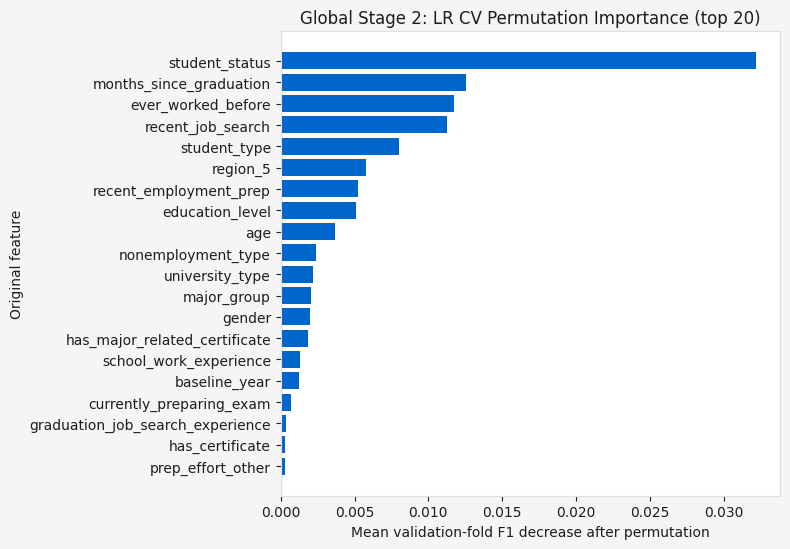

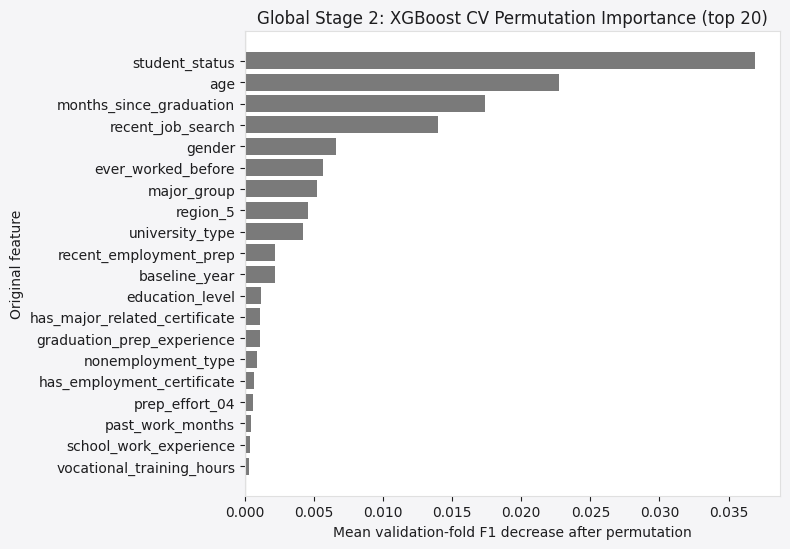

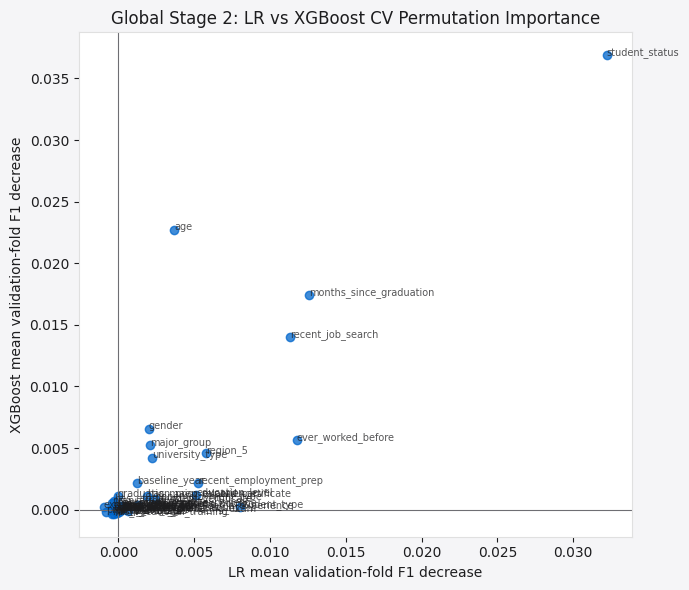

In [5]:
def plot_horizontal(frame, value_column, title, color, *, top_n=20, x_label=None):
    plotted = frame.nlargest(top_n, value_column).sort_values(value_column)
    fig, ax = plt.subplots(figsize=(8, max(5, top_n * 0.28)))
    ax.barh(plotted['feature'], plotted[value_column], color=color)
    ax.axvline(0, color='#6e6e73', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel(x_label or value_column)
    ax.set_ylabel('Original feature')
    plt.tight_layout()
    plt.show()

# 1. LR CV Permutation Importance
plot_horizontal(analyses['logistic_regression'].permutation_summary, 'importance_mean',
                'Global Stage 2: LR CV Permutation Importance (top 20)', COLORS['logistic_regression'],
                x_label='Mean validation-fold F1 decrease after permutation')

# 2. XGB CV Permutation Importance
plot_horizontal(analyses['xgboost'].permutation_summary, 'importance_mean',
                'Global Stage 2: XGBoost CV Permutation Importance (top 20)', COLORS['xgboost'],
                x_label='Mean validation-fold F1 decrease after permutation')

# 3. 두 모델 Permutation Importance 비교
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(feature_summary['lr_permutation_importance_mean'],
           feature_summary['xgb_permutation_importance_mean'], color='#0066cc', alpha=0.75)
for _, row in feature_summary.iterrows():
    ax.annotate(row['feature'], (row['lr_permutation_importance_mean'], row['xgb_permutation_importance_mean']),
                fontsize=7, alpha=0.75)
ax.axhline(0, color='#6e6e73', linewidth=0.8)
ax.axvline(0, color='#6e6e73', linewidth=0.8)
ax.set_title('Global Stage 2: LR vs XGBoost CV Permutation Importance')
ax.set_xlabel('LR mean validation-fold F1 decrease')
ax.set_ylabel('XGBoost mean validation-fold F1 decrease')
plt.tight_layout()
plt.show()

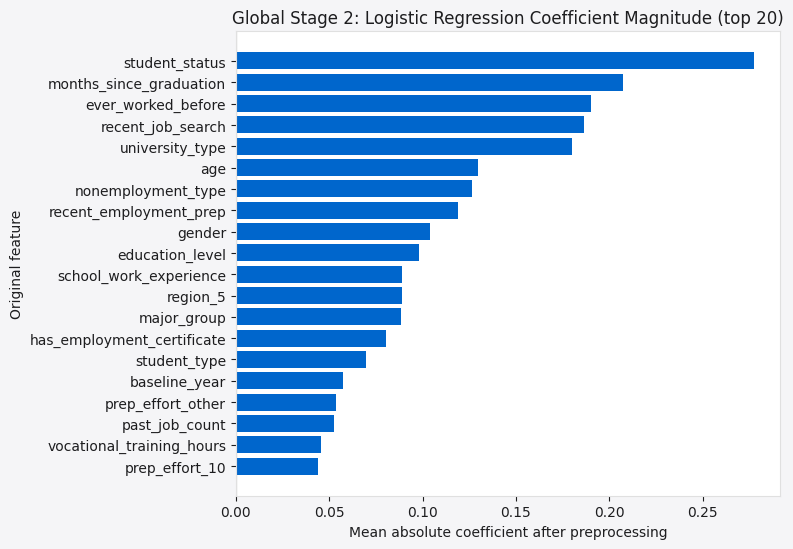

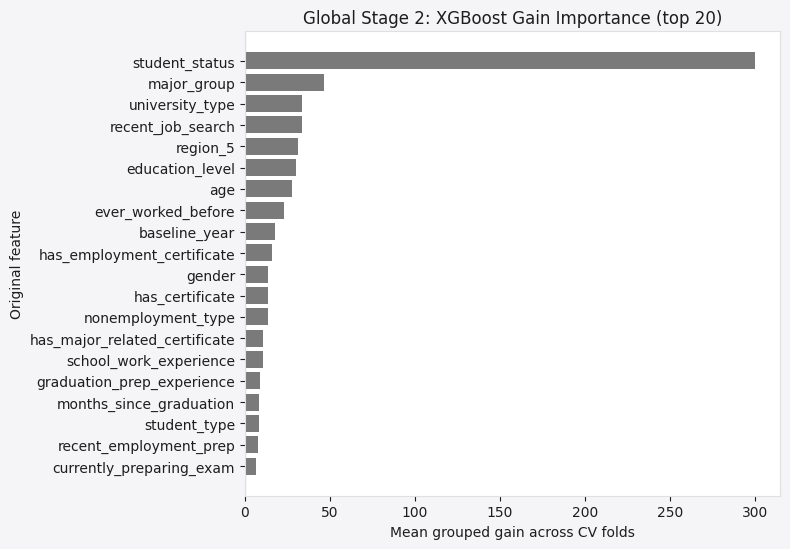

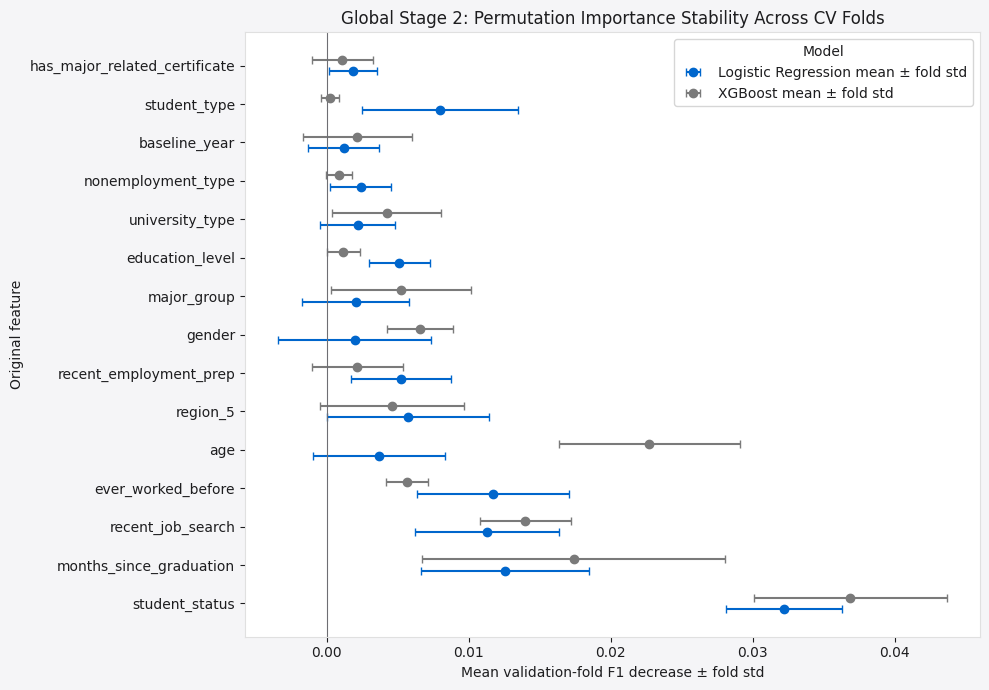

,stability_plot_features
0,student_status
1,months_since_graduation
2,recent_job_search
3,ever_worked_before
4,age
5,region_5
6,recent_employment_prep
7,gender
8,major_group
9,education_level


In [6]:
# 4. Logistic Regression coefficient magnitude
plot_horizontal(analyses['logistic_regression'].coefficient_summary, 'coefficient_magnitude',
                'Global Stage 2: Logistic Regression Coefficient Magnitude (top 20)', '#0066cc',
                x_label='Mean absolute coefficient after preprocessing')

# 5. XGBoost gain importance
plot_horizontal(analyses['xgboost'].xgb_importance, 'gain',
                'Global Stage 2: XGBoost Gain Importance (top 20)', '#7a7a7a',
                x_label='Mean grouped gain across CV folds')

# 6. Feature별 fold importance stability: 평균 permutation importance 상위 15개 원 Feature의 fold 값
feature_summary['combined_permutation_rank'] = (
    feature_summary['lr_permutation_rank'] + feature_summary['xgb_permutation_rank']
)
stability_features = feature_summary.nsmallest(15, 'combined_permutation_rank')['feature'].tolist()
fold_data = pd.concat([
    analyses[name].permutation_fold.assign(model=LABELS[name])
    for name in official_models
])
fold_data = fold_data[fold_data['feature'].isin(stability_features)]
stability_table = (fold_data.groupby(['model', 'feature'], sort=False)['importance_mean']
                   .agg(fold_mean='mean', fold_std=lambda values: values.std(ddof=0)).reset_index())
fig, ax = plt.subplots(figsize=(10, 7))
positions = np.arange(len(stability_features))
for offset, model_name in zip((-0.15, 0.15), official_models):
    subset = stability_table[stability_table['model'] == LABELS[model_name]].set_index('feature').reindex(stability_features)
    ax.errorbar(subset['fold_mean'], positions + offset, xerr=subset['fold_std'], fmt='o', capsize=3,
                color=COLORS[model_name], label=f"{LABELS[model_name]} mean ± fold std")
ax.axvline(0, color='#6e6e73', linewidth=0.8)
ax.set_title('Global Stage 2: Permutation Importance Stability Across CV Folds')
ax.set_xlabel('Mean validation-fold F1 decrease ± fold std')
ax.set_ylabel('Original feature')
ax.set_yticks(positions, stability_features)
ax.legend(title='Model')
plt.tight_layout()
plt.show()
display(pd.DataFrame({'stability_plot_features': stability_features}))

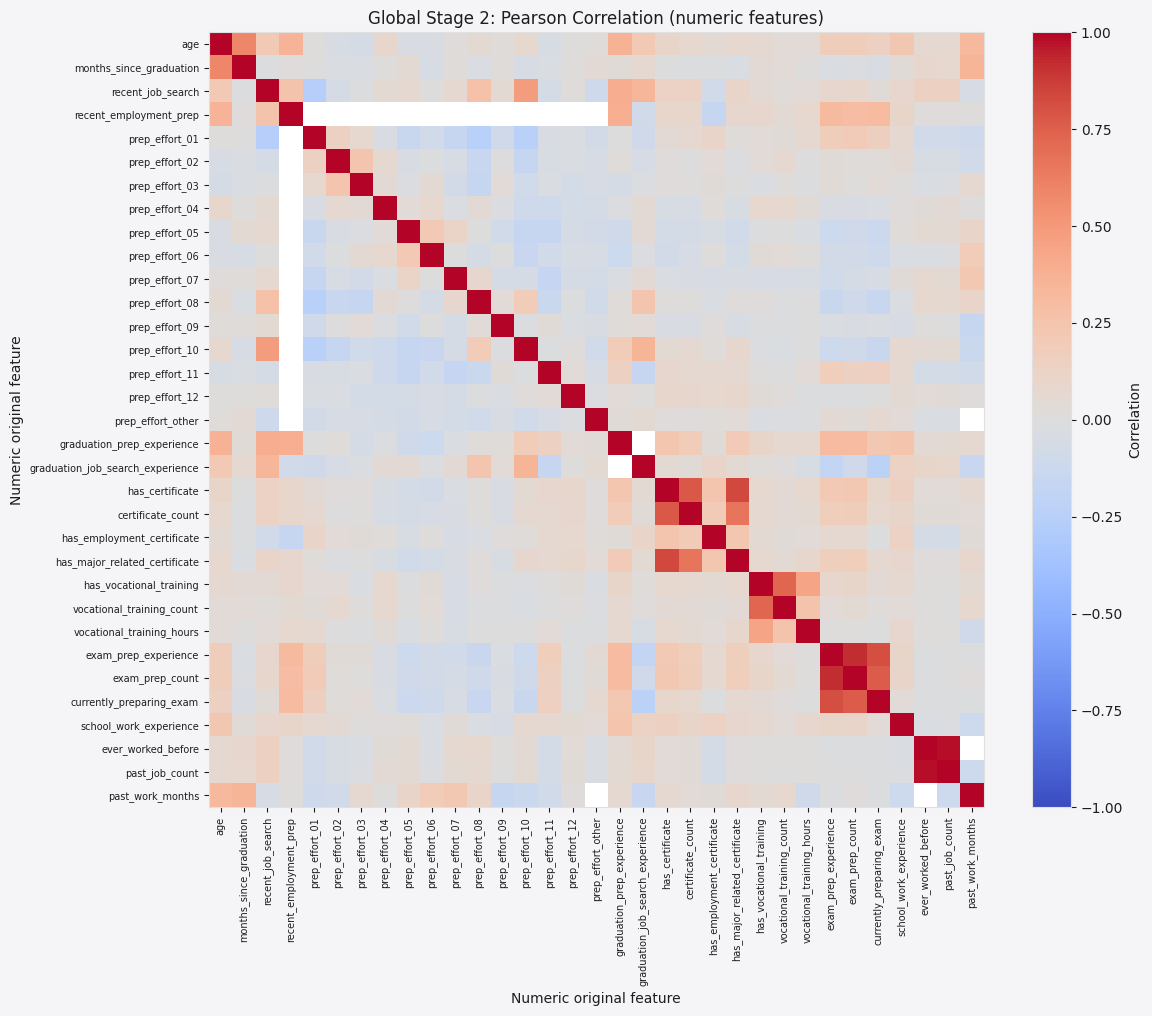

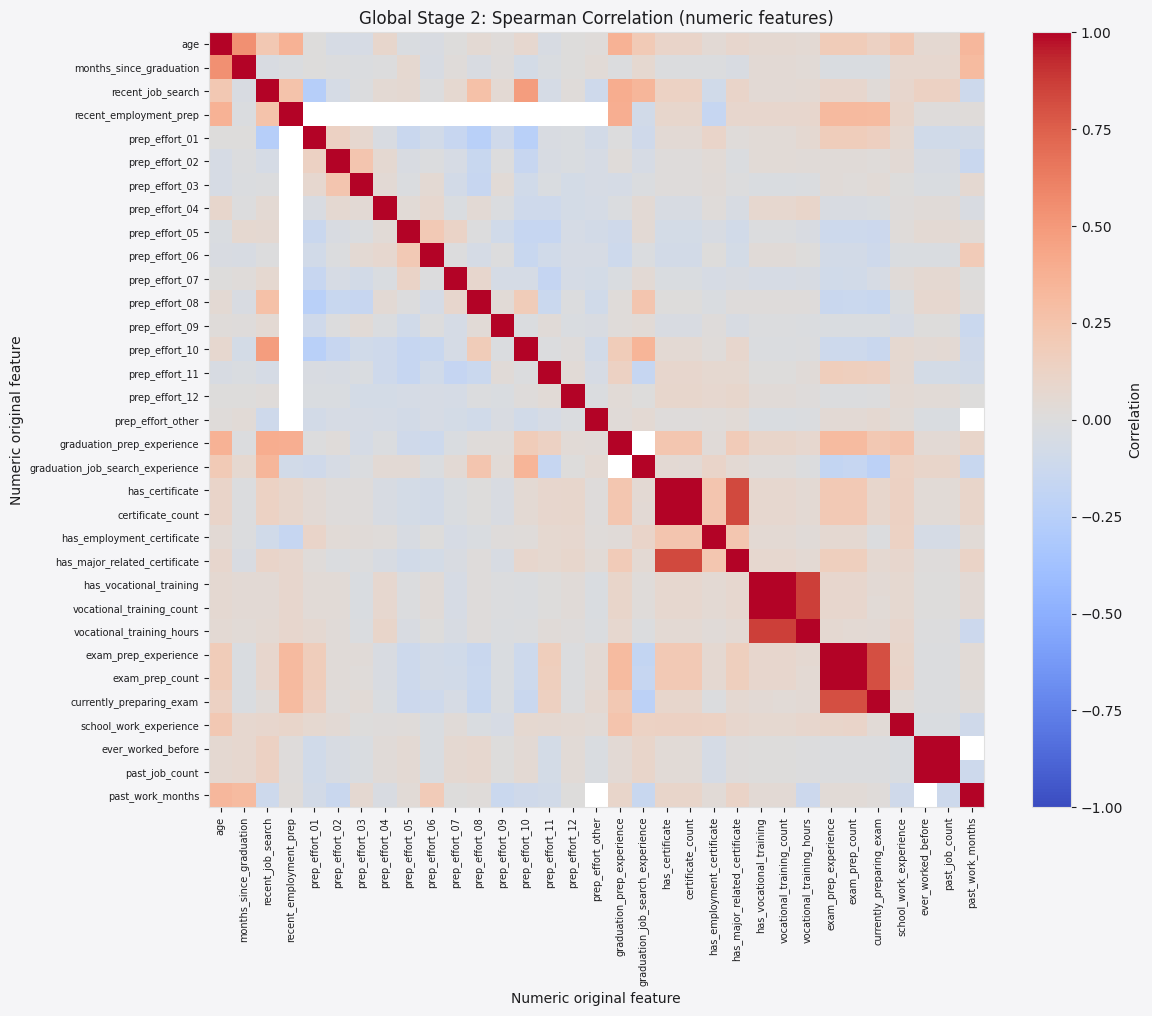

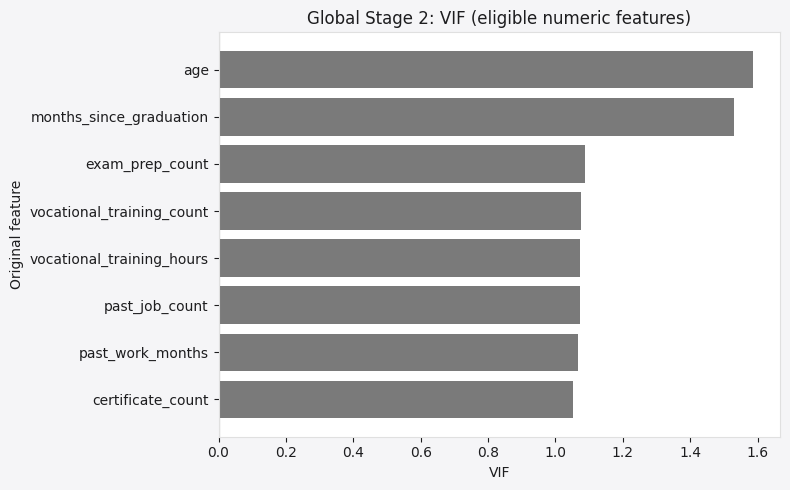

,feature,vif
0,age,1.587043
1,months_since_graduation,1.530210
2,exam_prep_count,1.088296
3,vocational_training_count,1.076344
4,vocational_training_hours,1.074200
5,past_job_count,1.071782
6,past_work_months,1.067285
7,certificate_count,1.051134


In [7]:
def plot_heatmap(matrix, title):
    fig, ax = plt.subplots(figsize=(12, 10))
    image = ax.imshow(matrix.to_numpy(), vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(matrix.index)), matrix.index, fontsize=7)
    ax.set_title(title)
    ax.set_xlabel('Numeric original feature')
    ax.set_ylabel('Numeric original feature')
    fig.colorbar(image, ax=ax, label='Correlation')
    plt.tight_layout()
    plt.show()

# 7-8. Pearson / Spearman correlation heatmaps (numeric original features only)
plot_heatmap(pearson, 'Global Stage 2: Pearson Correlation (numeric features)')
plot_heatmap(spearman, 'Global Stage 2: Spearman Correlation (numeric features)')

# 9. VIF: one-hot categorical columns and binary/low-variation numeric features are excluded.
plot_horizontal(vif_table, 'vif', 'Global Stage 2: VIF (eligible numeric features)', '#7a7a7a',
                top_n=len(vif_table), x_label='VIF')
display(vif_table)

## Feature selection용 종합표

아래 표는 42개 원 Feature의 Train 내부 분석값을 나란히 제공한다. 표는 Feature 삭제나 최종 목록 생성을 수행하지 않는다. 어떤 Feature를 사용할지는 사람이 직접 결정한다.

In [8]:
display(feature_summary)

# 재학습 없이 표·그래프를 다시 볼 수 있도록 Stage 2 분석표를 저장한다.
ANALYSIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
paths = {
    'feature_selection_summary': ANALYSIS_OUTPUT_DIR / 'feature_selection_summary.csv',
    'lr_permutation_summary': ANALYSIS_OUTPUT_DIR / 'logistic_regression_permutation_summary.csv',
    'lr_permutation_fold': ANALYSIS_OUTPUT_DIR / 'logistic_regression_permutation_fold.csv',
    'lr_coefficients': ANALYSIS_OUTPUT_DIR / 'logistic_regression_coefficient_summary.csv',
    'xgb_permutation_summary': ANALYSIS_OUTPUT_DIR / 'xgboost_permutation_summary.csv',
    'xgb_permutation_fold': ANALYSIS_OUTPUT_DIR / 'xgboost_permutation_fold.csv',
    'xgb_importance': ANALYSIS_OUTPUT_DIR / 'xgboost_importance.csv',
    'pearson': ANALYSIS_OUTPUT_DIR / 'pearson_correlation.csv',
    'spearman': ANALYSIS_OUTPUT_DIR / 'spearman_correlation.csv',
    'high_correlation_pairs': ANALYSIS_OUTPUT_DIR / 'high_correlation_pairs.csv',
    'vif': ANALYSIS_OUTPUT_DIR / 'numeric_vif.csv',
    'vif_scope': ANALYSIS_OUTPUT_DIR / 'numeric_vif_scope.csv',
}
feature_summary.to_csv(paths['feature_selection_summary'], index=False)
analyses['logistic_regression'].permutation_summary.to_csv(paths['lr_permutation_summary'], index=False)
analyses['logistic_regression'].permutation_fold.to_csv(paths['lr_permutation_fold'], index=False)
analyses['logistic_regression'].coefficient_summary.to_csv(paths['lr_coefficients'], index=False)
analyses['xgboost'].permutation_summary.to_csv(paths['xgb_permutation_summary'], index=False)
analyses['xgboost'].permutation_fold.to_csv(paths['xgb_permutation_fold'], index=False)
analyses['xgboost'].xgb_importance.to_csv(paths['xgb_importance'], index=False)
pearson.to_csv(paths['pearson'])
spearman.to_csv(paths['spearman'])
high_correlation_pairs.to_csv(paths['high_correlation_pairs'], index=False)
vif_table.to_csv(paths['vif'], index=False)
vif_scope.to_csv(paths['vif_scope'], index=False)
display(pd.DataFrame({'artifact': list(paths), 'path': [str(path) for path in paths.values()]}))

,feature,lr_permutation_importance_mean,lr_permutation_importance_std,lr_permutation_positive_fold_count,lr_permutation_rank,xgb_permutation_importance_mean,xgb_permutation_importance_std,xgb_permutation_positive_fold_count,xgb_permutation_rank,lr_coefficient_magnitude,lr_coefficient_mean,lr_coefficient_direction,xgb_gain,xgb_weight,max_abs_correlation,vif,combined_permutation_rank
0,gender,0.001991,0.005386,2,13,0.006583,0.002349,5,5,0.103737,-0.016795,negative,13.775989,159.0,NaN,NaN,18
1,age,0.003692,0.004617,4,9,0.022722,0.006381,5,2,0.129897,0.129897,positive,27.779439,299.8,0.583247,1.587043,11
2,region_5,0.005752,0.005709,4,6,0.004589,0.005056,3,8,0.089056,0.046517,positive,31.135584,227.8,NaN,NaN,14
3,baseline_year,0.001214,0.002490,4,16,0.002163,0.003829,2,11,0.057107,-0.037559,negative,17.503653,125.6,NaN,NaN,27
4,education_level,0.005123,0.002164,5,8,0.001165,0.001161,4,12,0.098175,-0.006600,negative,30.317665,78.2,NaN,NaN,20
5,student_status,0.032215,0.004080,5,1,0.036876,0.006774,5,1,0.277585,0.169592,positive,299.523654,45.6,NaN,NaN,2
6,student_type,0.008005,0.005479,4,5,0.000229,0.000615,3,22,0.069719,0.033871,positive,8.009774,15.6,NaN,NaN,27
7,university_type,0.002193,0.002661,3,11,0.004230,0.003846,4,9,0.180145,0.058088,positive,33.686295,126.0,NaN,NaN,20
8,major_group,0.002058,0.003753,3,12,0.005236,0.004945,4,7,0.088408,0.020918,positive,46.656492,281.2,NaN,NaN,19
9,months_since_graduation,0.012567,0.005924,5,2,0.017402,0.010665,5,3,0.207575,0.207575,positive,8.452597,610.4,0.583247,1.530210,5


,artifact,path
0,feature_selection_summary,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
1,lr_permutation_summary,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
2,lr_permutation_fold,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
3,lr_coefficients,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
4,xgb_permutation_summary,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
5,xgb_permutation_fold,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
6,xgb_importance,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
7,pearson,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
8,spearman,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
9,high_correlation_pairs,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
